# PM approval as a predictor of moral panic regarding illegal immigration

## Dataset: Prime Minister Approval Ratings (2010-2024)
(Main Predictor) 


In [1]:
import pandas as pd
pm_rates = pd.read_csv('datasets/pm_rates.csv')
pm_rates.head()


,Year,Month,Prime Minister,Rate,General Election
0,2010,June,Cameron,31.0,No
1,2010,July,Cameron,23.0,No
2,2010,August,Cameron,NaN,No
3,2010,September,Cameron,24.0,No
4,2010,October,Cameron,15.0,No


In [2]:
pm_rates['Rate'].describe()

count    145.000000
mean     -16.565517
std       18.119516
min      -59.000000
25%      -27.000000
50%      -17.000000
75%       -9.000000
max       35.000000
Name: Rate, dtype: float64

In [3]:
#changing str variables to int/float where needed for regression compatability:

#map month to its numerical code
month_map = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
            'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
            }

#apply map to the month column in pm_rates
pm_rates['month_num'] = pm_rates['Month'].map(month_map)

#change General Election values to binary
binary_map = {'No' : 0, 'Yes': 1}
pm_rates['election'] = pm_rates['General Election'].map(binary_map)
pm_rates.head()


,Year,Month,Prime Minister,Rate,General Election,month_num,election
0,2010,June,Cameron,31.0,No,6,0
1,2010,July,Cameron,23.0,No,7,0
2,2010,August,Cameron,NaN,No,8,0
3,2010,September,Cameron,24.0,No,9,0
4,2010,October,Cameron,15.0,No,10,0


In [4]:
#code PMs for multiple regression
#pm_rates['Prime Minister'].unique()


In [5]:
#pm_map = {'Cameron': 0, 'May': 1, 'Johnson': 2, 'Truss': 3, '

#pm_rates['pm_code'] = pm_rates['Prime Minister'].map(pm_map)
#pm_rates


In [6]:
pm_rates['Rate'].describe()

count    145.000000
mean     -16.565517
std       18.119516
min      -59.000000
25%      -27.000000
50%      -17.000000
75%       -9.000000
max       35.000000
Name: Rate, dtype: float64

In [7]:
#create new column with year and month, and store as a date within pandas (for time series analysis later):
pm_rates['date'] = pd.to_datetime(
    pm_rates['Year'].astype(str) + '-' + pm_rates['month_num'].astype(str),
    format = '%Y-%m') #capital Y = 4 digit year, lower case = 2

#make the new combined date the index for pm_rates:
pm_rates = pm_rates.set_index('date', drop = False) #drop = false so i can use it as my x axis in graphs later
pm_rates.head


<bound method NDFrame.head of             Year      Month Prime Minister  Rate General Election  month_num  \
date                                                                           
2010-06-01  2010       June        Cameron  31.0               No          6   
2010-07-01  2010       July        Cameron  23.0               No          7   
2010-08-01  2010     August        Cameron   NaN               No          8   
2010-09-01  2010  September        Cameron  24.0               No          9   
2010-10-01  2010    October        Cameron  15.0               No         10   
...          ...        ...            ...   ...              ...        ...   
2024-05-01  2024        May          Sunak -55.0               No          5   
2024-06-01  2024       June          Sunak -54.0               No          6   
2024-07-01  2024       July          Sunak -35.0              Yes          7   
2024-08-01  2024     August          Sunak   NaN               No          8   
2024-09-01

In [8]:
#filter df so its ready to compile into one df for the regression model:
pm_comp = pm_rates.drop(columns = ['Month', 'General Election'])
pm_comp


,Year,Prime Minister,Rate,month_num,election,date
date,,,,,,
2010-06-01,2010,Cameron,31.0,6,0,2010-06-01
2010-07-01,2010,Cameron,23.0,7,0,2010-07-01
2010-08-01,2010,Cameron,NaN,8,0,2010-08-01
2010-09-01,2010,Cameron,24.0,9,0,2010-09-01
2010-10-01,2010,Cameron,15.0,10,0,2010-10-01
...,...,...,...,...,...,...
2024-05-01,2024,Sunak,-55.0,5,0,2024-05-01
2024-06-01,2024,Sunak,-54.0,6,0,2024-06-01
2024-07-01,2024,Sunak,-35.0,7,1,2024-07-01


/opt/conda/lib/python3.11/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 27 rows containing missing values.


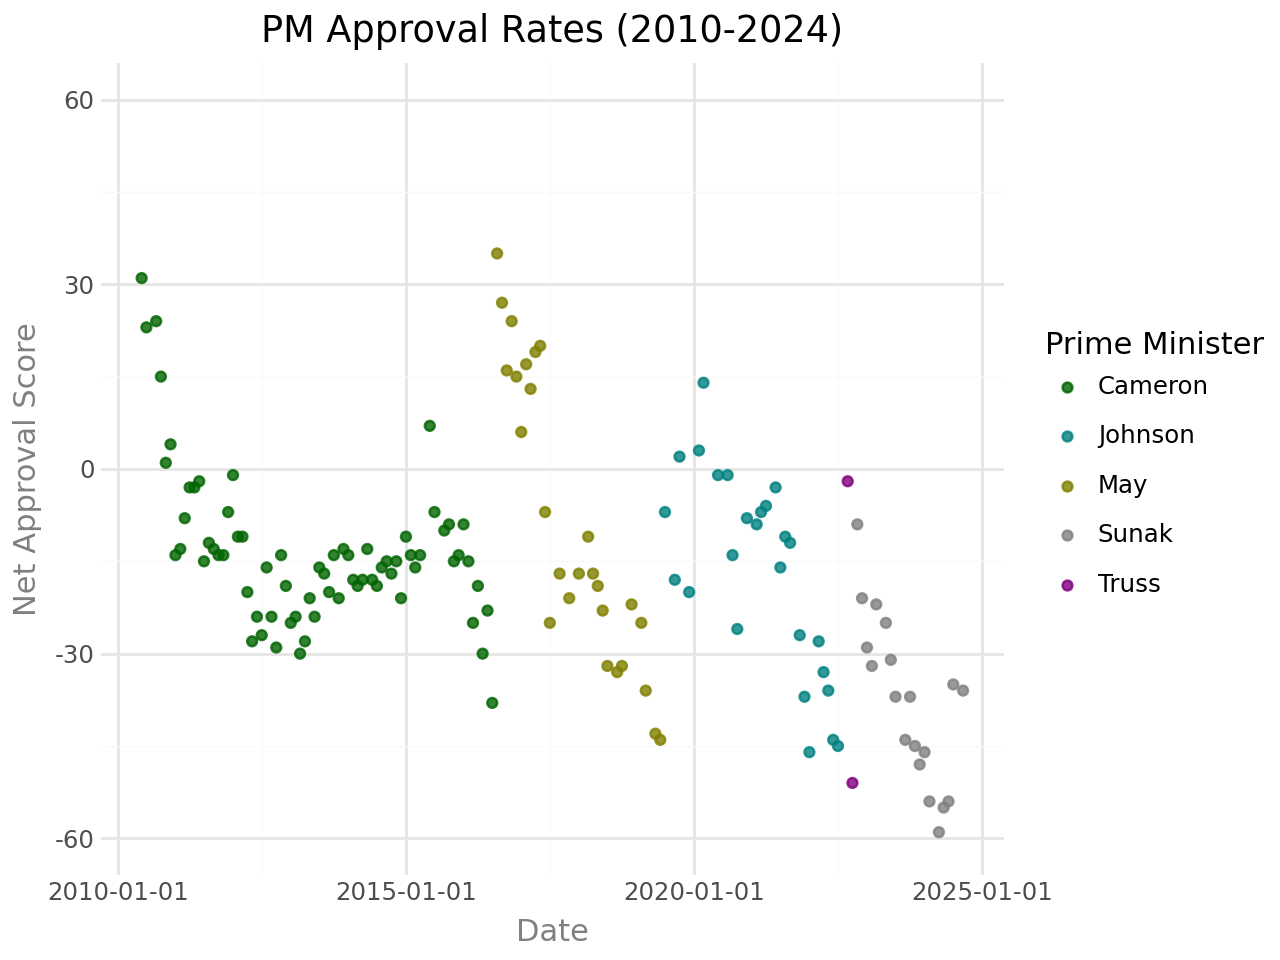

In [9]:
#graph of pm ratings over time

import plotnine as p9
(
p9.ggplot(pm_comp, p9.aes(x = 'date', y = 'Rate', color = 'Prime Minister'))
    +p9.geom_point(
        alpha = 0.8)
    +p9.ylim(-60,60) #to show all data clearly
    +p9.theme_minimal()
    +p9.labs(
        title = 'PM Approval Rates (2010-2024)', x= 'Date' , y= 'Net Approval Score')
    +p9.theme(
        axis_title = p9.element_text(colour = 'grey'))
    +p9.scale_colour_manual(values ={'Cameron':'darkgreen', 'Johnson':'teal', 'May':'olive', 'Sunak':'grey', 'Truss': 'purple'})
)


## Dataset: No. of Arrivals by Small Boat (2018-2025)
(Main Control)  
Proxy for 'real' prevelance of illegal immigration  

In [10]:
#asylum seeker arrival stats
asylum_real = pd.read_csv('datasets/asylum_arrivals_full.csv')
asylum_real = asylum_real.drop(columns = 'Total')
asylum_real.head()


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,2018,7,0,0,0,0,4,0,10,7,23,110,138
1,2019,45,88,66,80,150,163,195,342,210,75,151,278
2,2020,94,183,188,558,743,727,"1,111","1,469","1,949",474,761,209
3,2021,224,308,831,750,"1,627","2,177","3,512","3,053","4,602","2,701","6,971","1,770"
4,2022,"1,339",143,"3,066","2,143","2,916","3,140","3,673","8,574","8,054","6,900","4,082","1,744"


In [11]:
#pivoting table into long format so its compatible

asylum_real = asylum_real.melt(
    #keep year as column
    id_vars = ['Year'],
    #turn these column headings into values
    value_vars = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],

    #new column name:
    var_name = 'Month',
    #monthly values new column name:
    value_name = 'Arrival Stats'
)
asylum_real

,Year,Month,Arrival Stats
0,2018,Jan,7
1,2019,Jan,45
2,2020,Jan,94
3,2021,Jan,224
4,2022,Jan,"1,339"
...,...,...,...
91,2021,Dec,"1,770"
92,2022,Dec,"1,744"
93,2023,Dec,"1,077"
94,2024,Dec,"3,254"


In [12]:
#Problem identification: values seen as object not int, because values >1000 have commas.
print(asylum_real[['Arrival Stats']].dtypes)
print(asylum_real['Arrival Stats'].unique())


Arrival Stats    object
dtype: object
['7' '45' '94' '224' '1,339' '1,180' '1,335' '1,098' '0' '88' '183' '308'
 '143' '1,773' '920' '958' '66' '188' '831' '3,066' '840' '3,180' '4,586'
 '80' '558' '750' '2,143' '2,153' '2,132' '4,432' '150' '743' '1,627'
 '2,916' '1,664' '2,881' '3,738' '4' '163' '727' '2,177' '3,140' '3,823'
 '3,041' '5,170' '195' '1,111' '3,512' '3,673' '3,299' '3,414' '5,454'
 '10' '342' '1,469' '3,053' '8,574' '5,369' '4,149' '3,567' '210' '1,949'
 '4,602' '8,054' '4,729' '4,192' '5,084' '23' '75' '474' '2,701' '6,900'
 '1,869' '5,417' '2,867' '110' '151' '761' '6,971' '4,082' '1,661' '2,901'
 '2,338' '138' '278' '209' '1,770' '1,744' '1,077' '3,254' '2,180']


In [13]:
#this will be problem for graphs and zscore calculations, therefore:
asylum_real['Arrival Stats'] = asylum_real['Arrival Stats'].str.replace(',', '')
asylum_real['Arrival Stats'] = asylum_real['Arrival Stats'].astype(int)

#making column header compatible with code:
asylum_real = asylum_real.rename(columns={'Arrival Stats': 'arrival_stats'})
asylum_real


,Year,Month,arrival_stats
0,2018,Jan,7
1,2019,Jan,45
2,2020,Jan,94
3,2021,Jan,224
4,2022,Jan,1339
...,...,...,...
91,2021,Dec,1770
92,2022,Dec,1744
93,2023,Dec,1077
94,2024,Dec,3254


In [14]:
#dtype check
print(asylum_real[['arrival_stats']].dtypes)
print(asylum_real['arrival_stats'].unique())

arrival_stats    int64
dtype: object
[   7   45   94  224 1339 1180 1335 1098    0   88  183  308  143 1773
  920  958   66  188  831 3066  840 3180 4586   80  558  750 2143 2153
 2132 4432  150  743 1627 2916 1664 2881 3738    4  163  727 2177 3140
 3823 3041 5170  195 1111 3512 3673 3299 3414 5454   10  342 1469 3053
 8574 5369 4149 3567  210 1949 4602 8054 4729 4192 5084   23   75  474
 2701 6900 1869 5417 2867  110  151  761 6971 4082 1661 2901 2338  138
  278  209 1770 1744 1077 3254 2180]


In [15]:
#check
print(asylum_real.columns.tolist())

['Year', 'Month', 'arrival_stats']


In [16]:
asylum_real['arrival_stats'].describe()

count      96.000000
mean     2006.593750
std      2010.495119
min         0.000000
25%       193.250000
50%      1548.000000
75%      3198.500000
max      8574.000000
Name: arrival_stats, dtype: float64

In [17]:
#new month map for shorthand in asylum_real:
short_month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
            'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
            }

#making column with months as numbers:
asylum_real['month_num'] = asylum_real['Month'].map(short_month_map)

#concatenating Year and month_num into column: date
asylum_real['date'] = pd.to_datetime(
    asylum_real['Year'].astype(str) + '-' + asylum_real['month_num'].astype(str), 
    format = '%Y-%m')

#set date as index and sort by index date:
asylum_real = asylum_real.set_index('date').sort_index()

asylum_real.head()


,Year,Month,arrival_stats,month_num
date,,,,
2018-01-01,2018,Jan,7,1
2018-02-01,2018,Feb,0,2
2018-03-01,2018,Mar,0,3
2018-04-01,2018,Apr,0,4
2018-05-01,2018,May,0,5


In [18]:
#filter for compiled regression df:
asylum_comp = asylum_real['arrival_stats']

#check max value of arrivals to set y limit on graph:
asylum_comp.max()


np.int64(8574)

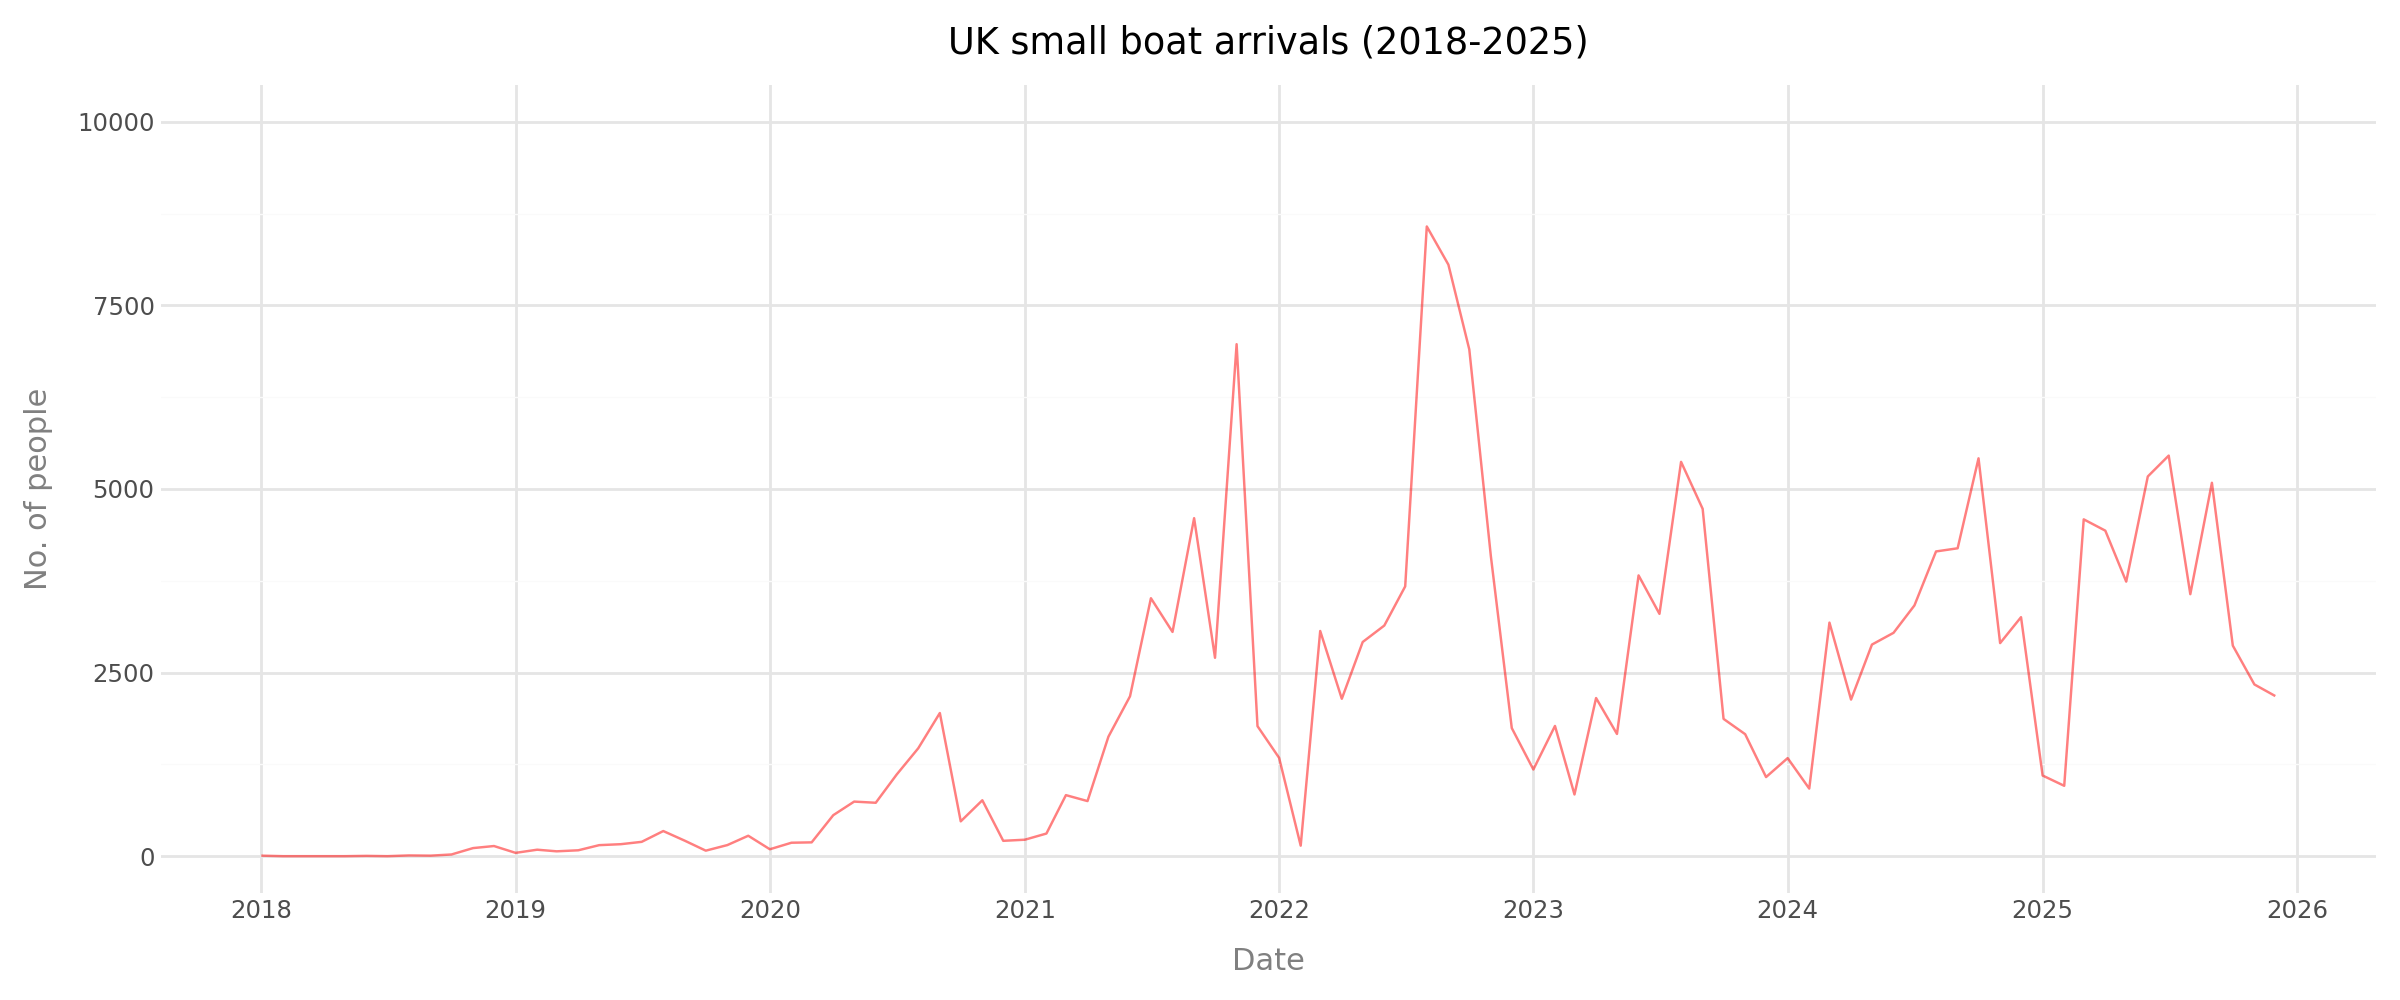

In [19]:
#make plot to show trend for asylum stats over time
# .reset_index() to reset date for x axis

(
p9.ggplot(asylum_comp.reset_index(), p9.aes(x = 'date', y = 'arrival_stats'))
    +p9.geom_line(
        alpha = 0.5, color = 'red')
    +p9.labs(
        title = 'UK small boat arrivals (2018-2025)', x = 'Date', y = 'No. of people')
    +p9.theme_minimal()
    +p9.theme(
        figure_size=(12,5),
        axis_title = p9.element_text(colour = 'grey'))
    +p9.scale_x_date(date_breaks = "1 year", date_minor_breaks = "1 year", date_labels = "%Y")
    +p9.scale_y_continuous(limits=(0, 10000))

)


## Dataset: Volume of Media Coverage
(Outcome)  
Proxy for moral panic when controlled by 'real' stats

In [20]:
asylum_media = pd.read_csv('datasets/newsbank.csv')
asylum_media.head()


,Year,Month,Volume of Articles
0,2018,January,334
1,2018,February,178
2,2018,March,105
3,2018,April,322
4,2018,May,192


In [21]:
#make column header compatible with code
asylum_media = asylum_media.rename(columns={'Volume of Articles': 'article_vol'})
asylum_media.head()


,Year,Month,article_vol
0,2018,January,334
1,2018,February,178
2,2018,March,105
3,2018,April,322
4,2018,May,192


In [22]:
asylum_media['article_vol'].describe()

count      96.000000
mean      486.864583
std       329.124600
min       105.000000
25%       215.500000
50%       388.500000
75%       677.000000
max      1651.000000
Name: article_vol, dtype: float64

In [23]:
#there was NaN values in month_num after initial map attempt
#code below showed this was because of white spaces in Month values for February.
print(repr(asylum_media['Month'][1]))

#remove any white spaces from within the Month values
asylum_media['Month'] = asylum_media['Month'].str.strip()


'February '


In [24]:
#assign Month values to numerical counterparts
asylum_media['month_num'] = asylum_media['Month'].map(month_map)

#check
print(asylum_media['month_num'].isna().sum())
#check
asylum_media[asylum_media['Month'] == 'February']

0


,Year,Month,article_vol,month_num
1,2018,February,178,2
13,2019,February,216,2
25,2020,February,214,2
37,2021,February,127,2
49,2022,February,206,2
61,2023,February,365,2
73,2024,February,649,2
85,2025,February,863,2


In [25]:
#combining year and month as date:
asylum_media['date'] = pd.to_datetime(
    asylum_media['Year'].astype(str) + '-' + asylum_media['month_num'].astype(str), #month_num was a float: couldn't be translated
    format = '%Y-%m'
)

#set combined Date as index:
asylum_media = asylum_media.set_index('date')

#removing columns I don't need for the compiled regression dataset:
media_comp = asylum_media['article_vol']
media_comp


date
2018-01-01     334
2018-02-01     178
2018-03-01     105
2018-04-01     322
2018-05-01     192
              ... 
2025-08-01    1651
2025-09-01    1474
2025-10-01     953
2025-11-01     815
2025-12-01     651
Name: article_vol, Length: 96, dtype: int64

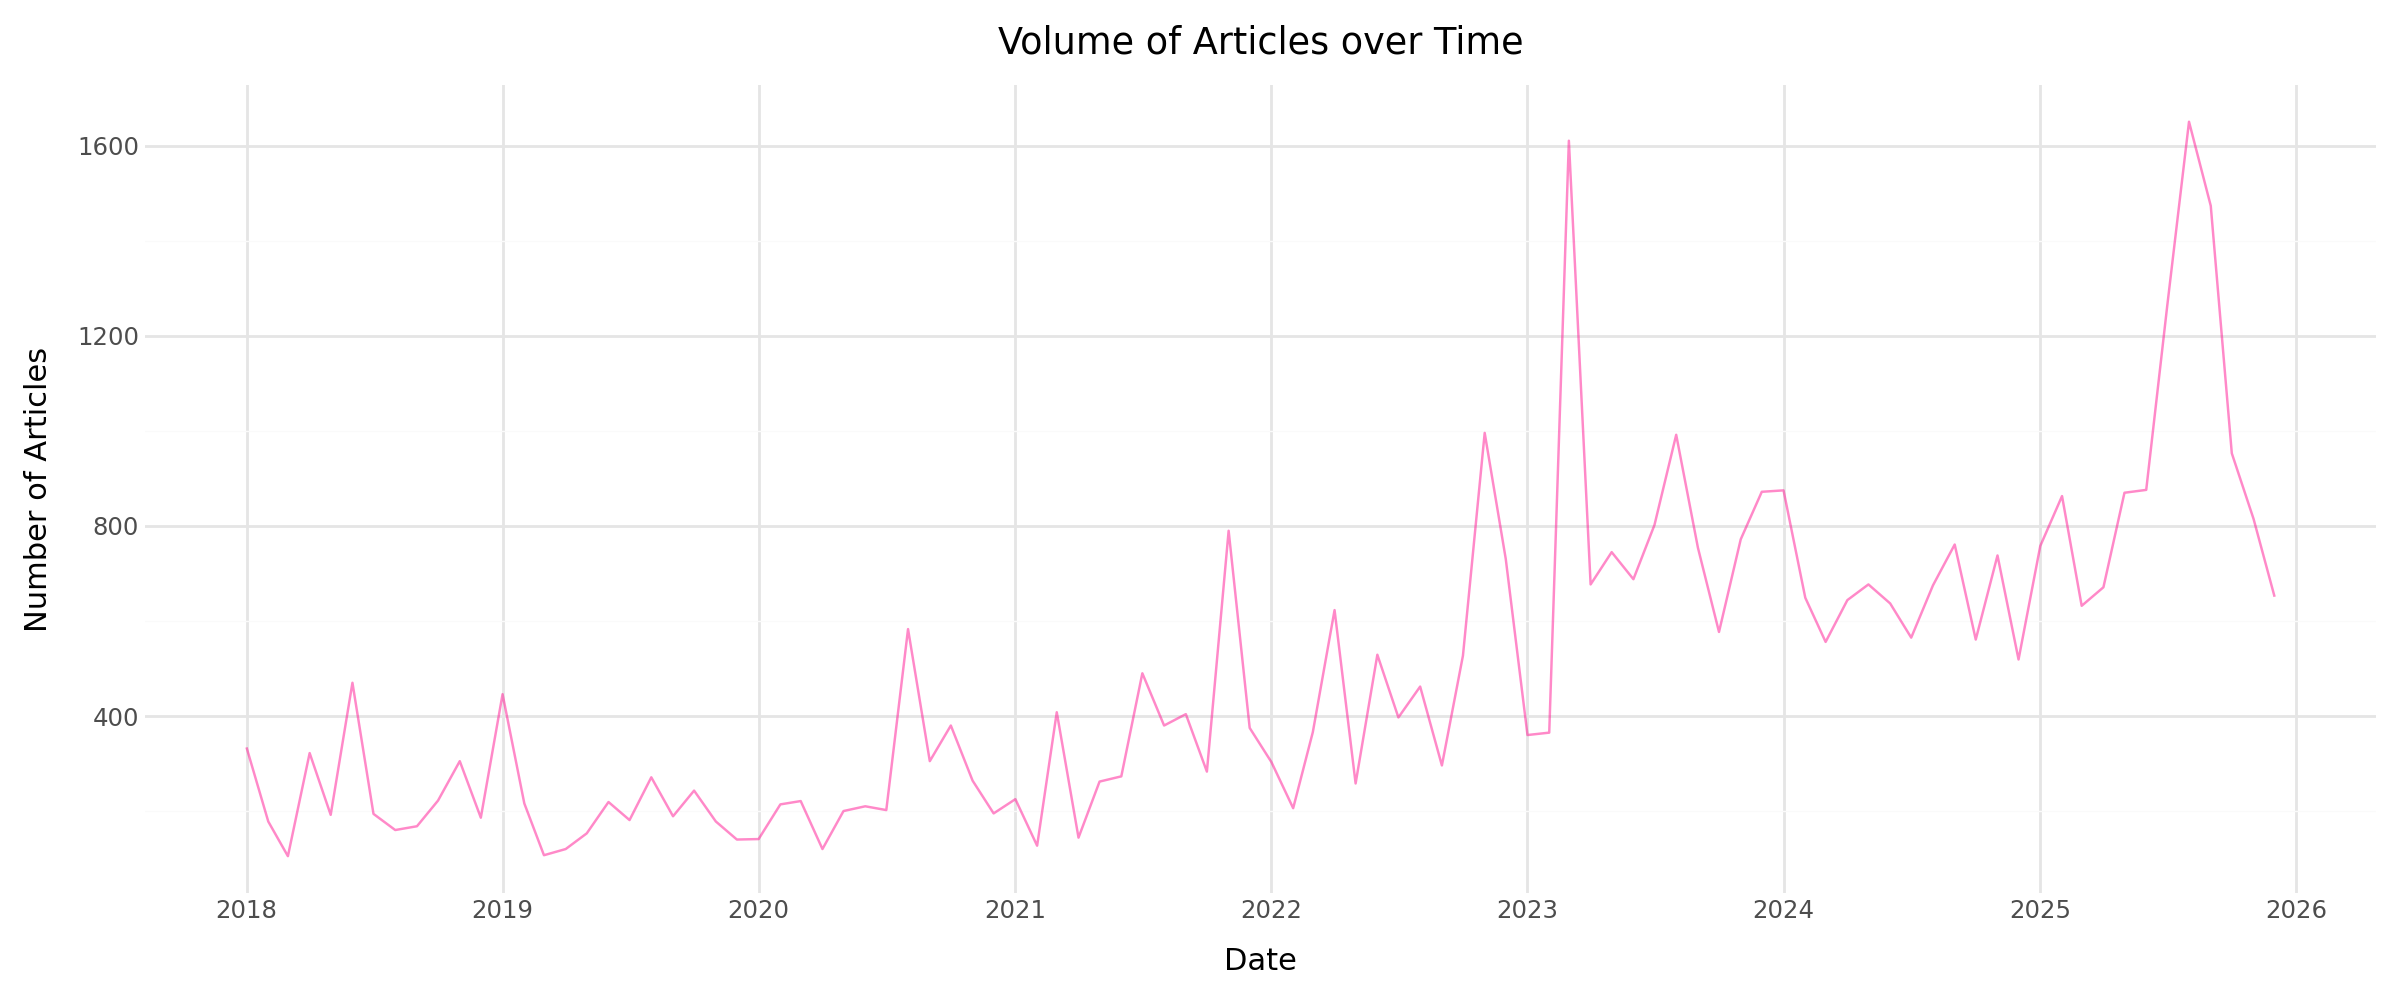

In [26]:
#graph to show media coverage over time
(
p9.ggplot(media_comp.reset_index(), p9.aes(x = 'date', y = 'article_vol'))
    +p9.geom_line(
        alpha = 0.5, colour = 'deeppink')
    +p9.scale_x_date(date_breaks = "1 year", date_minor_breaks = "1 year", date_labels = "%Y")
    +p9.labs(title = 'Volume of Articles over Time', x = 'Date', y = 'Number of Articles')
    +p9.theme_minimal()
    +p9.theme(figure_size=(12,5))

)

## Compilation of Datasets

In [27]:
pm_comp.head()

,Year,Prime Minister,Rate,month_num,election,date
date,,,,,,
2010-06-01,2010,Cameron,31.0,6,0,2010-06-01
2010-07-01,2010,Cameron,23.0,7,0,2010-07-01
2010-08-01,2010,Cameron,NaN,8,0,2010-08-01
2010-09-01,2010,Cameron,24.0,9,0,2010-09-01
2010-10-01,2010,Cameron,15.0,10,0,2010-10-01


In [28]:
#compile media_comp, asylum_comp & pm_comp to one dataset
compiled_df = pm_comp.join([media_comp, asylum_comp], how = 'inner') #inner means only keep dataframes that exist in all datasets
compiled_df.head()


,Year,Prime Minister,Rate,month_num,election,date,article_vol,arrival_stats
date,,,,,,,,
2018-01-01,2018,May,-17.0,1,0,2018-01-01,334,7
2018-02-01,2018,May,NaN,2,0,2018-02-01,178,0
2018-03-01,2018,May,-11.0,3,0,2018-03-01,105,0
2018-04-01,2018,May,-17.0,4,0,2018-04-01,322,0
2018-05-01,2018,May,-19.0,5,0,2018-05-01,192,0


In [29]:
#rename columns so they're clear with new context: this is the dataframe to be used in regression model
compiled_df = compiled_df.rename(columns = {'Prime Minister': 'pm', 'Rate': 'pm_rating', 'arrival_stats': 'boat_arrival_num'})
compiled_df.head()


,Year,pm,pm_rating,month_num,election,date,article_vol,boat_arrival_num
date,,,,,,,,
2018-01-01,2018,May,-17.0,1,0,2018-01-01,334,7
2018-02-01,2018,May,NaN,2,0,2018-02-01,178,0
2018-03-01,2018,May,-11.0,3,0,2018-03-01,105,0
2018-04-01,2018,May,-17.0,4,0,2018-04-01,322,0
2018-05-01,2018,May,-19.0,5,0,2018-05-01,192,0


In [30]:
#descriptive stats in one df
compiled_df[['pm_rating', 'article_vol', 'boat_arrival_num']].describe()

,pm_rating,article_vol,boat_arrival_num
count,60.000000,81.000000,81.000000
mean,-26.033333,412.876543,1723.320988
std,17.099873,272.121544,1972.865928
min,-59.000000,105.000000,0.000000
25%,-37.000000,202.000000,151.000000
50%,-26.500000,322.000000,1077.000000
75%,-11.750000,583.000000,2916.000000
max,14.000000,1611.000000,8574.000000


## Z-score standardisation

In [31]:
#graph showing all three trends over time together
import matplotlib.pyplot as plt
import numpy

from scipy.stats import zscore


In [32]:
compiled_df.head()

,Year,pm,pm_rating,month_num,election,date,article_vol,boat_arrival_num
date,,,,,,,,
2018-01-01,2018,May,-17.0,1,0,2018-01-01,334,7
2018-02-01,2018,May,NaN,2,0,2018-02-01,178,0
2018-03-01,2018,May,-11.0,3,0,2018-03-01,105,0
2018-04-01,2018,May,-17.0,4,0,2018-04-01,322,0
2018-05-01,2018,May,-19.0,5,0,2018-05-01,192,0


In [33]:
#create cross correlation for election - article vol to see where best lag is then apply for regression

In [34]:
#as there are still NaN values in 'pm_rating' i need to add something to tell it to ignore those values.
#.apply can only take one argument so i need to create a function to condense zscore and the NaN skip.
#lamba because its a short function i dont need to repeat.
zscore_df = compiled_df[['pm_rating', 'article_vol', 'boat_arrival_num', ]].apply(lambda x: zscore(x, nan_policy='omit'))

# i will add columns from compiled_df that i want to use as potential control variables
zscore_df[['Year', 'pm', 'month_num', 'election']] = compiled_df[['Year', 'pm', 'month_num', 'election']]


In [35]:
#adding date column back so it can be used as x axis in graph
zscore_df = zscore_df.reset_index()
zscore_df.head()


,date,pm_rating,article_vol,boat_arrival_num,Year,pm,month_num,election
0,2018-01-01,0.532727,-0.291664,-0.875384,2018,May,1,0
1,2018-02-01,NaN,-0.868509,-0.878954,2018,May,2,0
2,2018-03-01,0.886568,-1.138443,-0.878954,2018,May,3,0
3,2018-04-01,0.532727,-0.336036,-0.878954,2018,May,4,0
4,2018-05-01,0.414780,-0.816741,-0.878954,2018,May,5,0


In [36]:
#create average zscore value for boat arrival number and article volume to get moral panic index:
zscore_df['moral_panic'] = (zscore_df['article_vol'] + zscore_df['boat_arrival_num'])/2
zscore_df.head()


,date,pm_rating,article_vol,boat_arrival_num,Year,pm,month_num,election,moral_panic
0,2018-01-01,0.532727,-0.291664,-0.875384,2018,May,1,0,-0.583524
1,2018-02-01,NaN,-0.868509,-0.878954,2018,May,2,0,-0.873731
2,2018-03-01,0.886568,-1.138443,-0.878954,2018,May,3,0,-1.008698
3,2018-04-01,0.532727,-0.336036,-0.878954,2018,May,4,0,-0.607495
4,2018-05-01,0.414780,-0.816741,-0.878954,2018,May,5,0,-0.847847


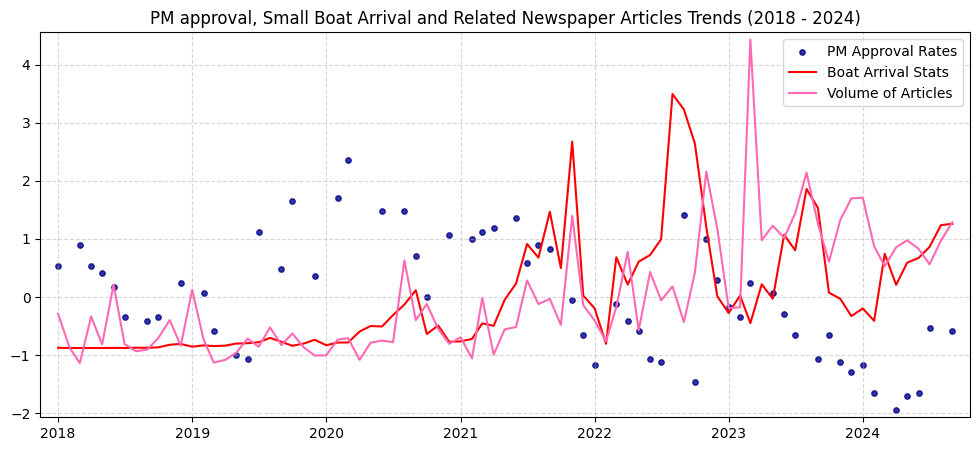

In [37]:
import matplotlib.pyplot as plt

#create graph showing 3 main variables
fig, ax = plt.subplots(figsize=(12,5))
ax.scatter(zscore_df['date'], zscore_df['pm_rating'], label = 'PM Approval Rates', color = 'darkblue', alpha = 0.8, s = 15)
ax.plot(zscore_df['date'], zscore_df['boat_arrival_num'], label = 'Boat Arrival Stats', color = 'red')
ax.plot(zscore_df['date'], zscore_df['article_vol'], label = 'Volume of Articles', color = 'hotpink')


plt.legend()
plt.title('PM approval, Small Boat Arrival and Related Newspaper Articles Trends (2018 - 2024)')

ax.grid(True, linestyle = '--', alpha = 0.5)
ax.margins(0.02) #where lines ended looked unatural before padding adjustment
plt.show()



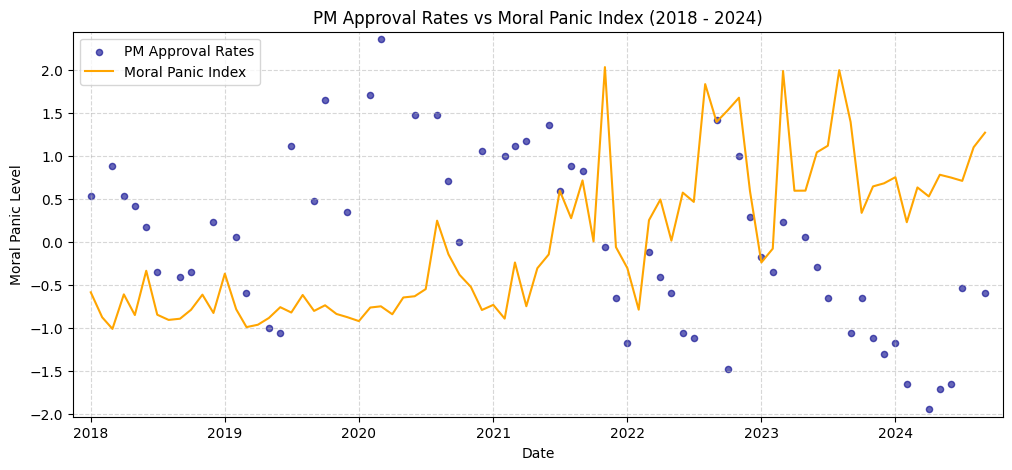

In [38]:
#create graph with average zscore of arrival stats and article volume as moral panic index - easier to interpret

fig, ax = plt.subplots(figsize=(12,5))
ax.scatter(zscore_df['date'], zscore_df['pm_rating'], label = 'PM Approval Rates', color = 'darkblue', alpha = 0.6, s = 20)
ax.plot(zscore_df['date'], zscore_df['moral_panic'], label = 'Moral Panic Index', color = 'orange')


plt.legend()
plt.title('PM Approval Rates vs Moral Panic Index (2018 - 2024)')
plt.xlabel('Date')
plt.ylabel('Moral Panic Level')

ax.grid(True, linestyle = '--', alpha = 0.5)
ax.margins(0.02)
plt.show()


In [39]:
timeshift_df = zscore_df[['pm_rating','article_vol', 'election']]
timeshift_df.head()


,pm_rating,article_vol,election
0,0.532727,-0.291664,0
1,NaN,-0.868509,0
2,0.886568,-1.138443,0
3,0.532727,-0.336036,0
4,0.414780,-0.816741,0


## Lag: Set from Cross Correlation

In [40]:
#i am seeing if article_vol can be predicted by pm_rating.
#pm_rating must come first in that relationship, so i am only testing positive lag.

#empty array for each lag correlation
corr = []
#I think 6 months is the upper limit on how long an effect could be reasonably expected to take,
#therefore i will test 0-6 months:
for lag in range(-6,0):
    correlation = zscore_df['pm_rating'].corr(zscore_df['article_vol'].shift(lag))
    corr.append(correlation)
    print(lag, correlation)


-6 -0.21677892180540131
-5 -0.40738234822640657
-4 -0.33230740291678895
-3 -0.30496686823227415
-2 -0.32873721223804747
-1 -0.4103303748512428


In [41]:
#Array turned into series to automate identifying the strongest correlation.
corr_s = pd.Series(corr, index=range(-6,0)) 

print('The strongest correlation is:', corr_s.abs().max().round(3), ', which occurs with a lag of', corr_s.abs().idxmax() , 'months.') #idxmax = corresponding index of maximum value
print('This means that pm_rating strongest correlation is with the volume of articles one month afterwards.')


The strongest correlation is: 0.41 , which occurs with a lag of -1 months.
This means that pm_rating strongest correlation is with the volume of articles one month afterwards.


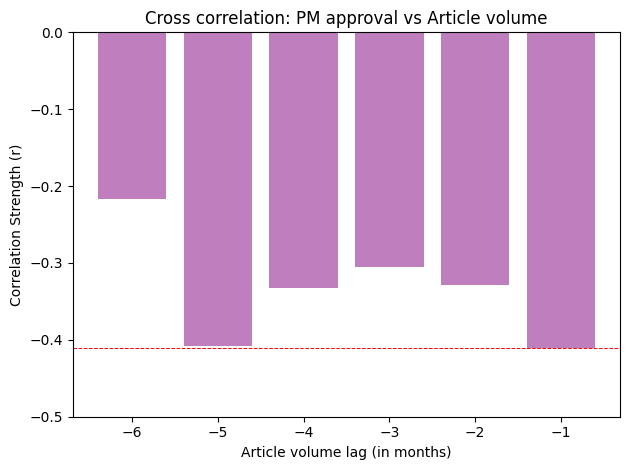

In [94]:
plt.bar(corr_s.index, corr_s.values, color = 'purple', alpha = 0.5)

plt.title('Cross correlation: PM approval vs Article volume')
plt.xlabel('Article volume lag (in months)')
plt.ylabel('Correlation Strength (r)')

plt.axhline(y= corr_s.min(), color = 'red', linestyle = '--', linewidth = 0.7)
plt.ylim(-0.5, 0)

plt.tight_layout()
plt.show()

In [43]:
#check for which timeshift matches current pm_rating with future article_vol: for self check
timeshift_df['shifted-1_pm'] = zscore_df['pm_rating'].shift(-1)
timeshift_df['shifted1_pm'] = zscore_df['pm_rating'].shift(1)
timeshift_df.head()
#from this i can see it is lag = 1 for pm_rating

/tmp/ipykernel_427/565554094.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_427/565554094.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,pm_rating,article_vol,election,shifted-1_pm,shifted1_pm
0,0.532727,-0.291664,0,NaN,NaN
1,NaN,-0.868509,0,0.886568,0.532727
2,0.886568,-1.138443,0,0.532727,NaN
3,0.532727,-0.336036,0,0.414780,0.886568
4,0.414780,-0.816741,0,0.178886,0.532727


In [44]:
#now that i know this, i will shift my pm_rating forward 1 month and use that in my regression model.
#i shift pm_rating rather that article_vol as article_vol is my outcome, if i shift it all other control variables will be measured against values from a month ahead.
zscore_df['shifted_pm'] = zscore_df['pm_rating'].shift(1)
zscore_df.head()


,date,pm_rating,article_vol,boat_arrival_num,Year,pm,month_num,election,moral_panic,shifted_pm
0,2018-01-01,0.532727,-0.291664,-0.875384,2018,May,1,0,-0.583524,NaN
1,2018-02-01,NaN,-0.868509,-0.878954,2018,May,2,0,-0.873731,0.532727
2,2018-03-01,0.886568,-1.138443,-0.878954,2018,May,3,0,-1.008698,NaN
3,2018-04-01,0.532727,-0.336036,-0.878954,2018,May,4,0,-0.607495,0.886568
4,2018-05-01,0.414780,-0.816741,-0.878954,2018,May,5,0,-0.847847,0.532727


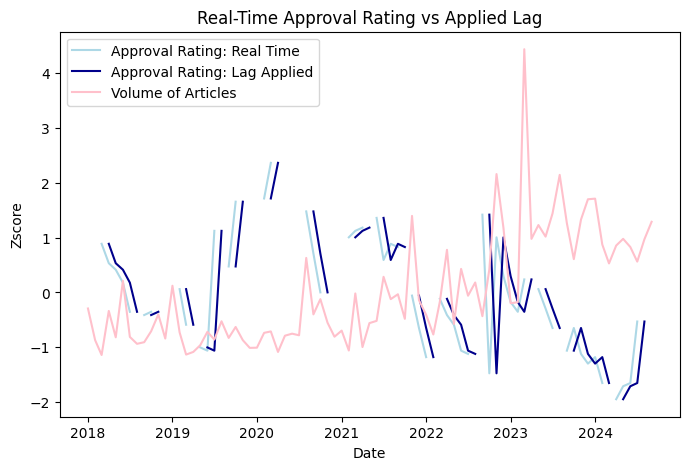

In [96]:
#graph to demonstrate the timehsift visually:
fig, ax = plt.subplots(figsize = (8,5))
ax.plot(zscore_df['date'],zscore_df['pm_rating'], label = 'Approval Rating: Real Time', color = 'lightblue')
ax.plot(zscore_df['date'], zscore_df['shifted_pm'], label = 'Approval Rating: Lag Applied', color = 'darkblue')
ax.plot(zscore_df['date'], zscore_df['article_vol'], label = 'Volume of Articles', color = 'pink')

plt.title('Real-Time Approval Rating vs Applied Lag')
plt.xlabel('Date')
plt.ylabel('Zscore')

plt.legend()

plt.show()

In [46]:
#time lag for election: checking for correlation of future elections with current article_vol.
#Therefore, i use a - shift on election.

#negative range because im asking: how is the current volume of articles affected by upcoming elections.
corr_elec = []
for lag in range(-6, 0):
    correlation = timeshift_df['article_vol'].corr(timeshift_df['election'].shift(lag))
    corr_elec.append(correlation)
    print(lag, correlation)

-6 0.09398491208227273
-5 0.011281943096275927
-4 0.008100620448125657
-3 0.008037217804377597
-2 0.032823907180146876
-1 -0.0006094999444887677


In [47]:
corr_elec_s = pd.Series(corr_elec)
print(f'The strongest correlation was: {corr_elec_s.abs().max().round(3)} which happened at lag {corr_elec_s.abs().idxmax()}. This is unexpected.')

zscore_df['election'].describe()


The strongest correlation was: 0.094 which happened at lag 0. This is unexpected.


count    81.000000
mean      0.024691
std       0.156150
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       1.000000
Name: election, dtype: float64

## Regression Models

Standard formula: Findings for report

In [48]:
#Minimum Model
#Type: Standard

import statsmodels.api as sm

formula = 'article_vol ~ shifted_pm + boat_arrival_num'
model_relationship = sm.formula.ols(formula = formula, data = zscore_df)
model_fit = model_relationship.fit()

#y_pred = model_fit.predict(zscore_df)

print(model_fit.summary())


                            OLS Regression Results                            
Dep. Variable:            article_vol   R-squared:                       0.280
Model:                            OLS   Adj. R-squared:                  0.254
Method:                 Least Squares   F-statistic:                     10.88
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           0.000102
Time:                        17:14:58   Log-Likelihood:                -75.808
No. Observations:                  59   AIC:                             157.6
Df Residuals:                      56   BIC:                             163.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.0919      0.117  

standard max model: Issue with pm multicollinearity

In [49]:
#Maximum Model
#Type: Standard

import statsmodels.api as sm

#stepwise reduction removed: Year & month_num. Removing 3rd least significant lowered r-squared.
formula = 'article_vol ~ shifted_pm + boat_arrival_num + pm + election'
model_relationship = sm.formula.ols(formula = formula, data = zscore_df)
model_fit = model_relationship.fit()

#y_pred = model_fit.predict(zscore_df)

print(model_fit.summary())


                            OLS Regression Results                            
Dep. Variable:            article_vol   R-squared:                       0.618
Model:                            OLS   Adj. R-squared:                  0.574
Method:                 Least Squares   F-statistic:                     14.01
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           2.08e-09
Time:                        17:14:58   Log-Likelihood:                -57.116
No. Observations:                  59   AIC:                             128.2
Df Residuals:                      52   BIC:                             142.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.3776      0.142  

Moral Panic Index: Excluded due to circularity

In [50]:
#Minimum Model
#Type: Moral Panic Index

import statsmodels.api as sm

formula = 'article_vol ~ moral_panic'
model_relationship = sm.formula.ols(formula = formula, data = zscore_df)
model_fit = model_relationship.fit()

#y_pred = model_fit.predict(zscore_df)

print(model_fit.summary())

                            OLS Regression Results                            
Dep. Variable:            article_vol   R-squared:                       0.733
Model:                            OLS   Adj. R-squared:                  0.729
Method:                 Least Squares   F-statistic:                     216.5
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           2.43e-24
Time:                        17:14:58   Log-Likelihood:                -61.504
No. Observations:                  81   AIC:                             127.0
Df Residuals:                      79   BIC:                             131.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept   -7.798e-17      0.058  -1.34e-15      

In [51]:
#Maximum Model
#Type: Moral Panic Index


import statsmodels.api as sm

#this formula excludes pm_rating and boat_arrival_num as they're captured through the moral panic index: moral_panic.
#stepwise selection: removed election. Removing 2nd least significant lowered r-squared value.
final_formula = 'article_vol ~ moral_panic + Year + month_num + pm'
final_model_relationship = sm.formula.ols(formula = final_formula, data = zscore_df)
final_model_fit = final_model_relationship.fit()

y_pred = final_model_fit.predict(zscore_df)

print(final_model_fit.summary())

                            OLS Regression Results                            
Dep. Variable:            article_vol   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     80.23
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           2.30e-30
Time:                        17:14:58   Log-Likelihood:                -33.304
No. Observations:                  81   AIC:                             80.61
Df Residuals:                      74   BIC:                             97.37
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     449.9673    139.469      3.226      

Interaction check formula: Excluded as combined variable is insignificant

In [52]:
#Minimum Model
#Type: Interaction Check

import statsmodels.api as sm

formula = 'article_vol ~ shifted_pm * boat_arrival_num'
model_relationship = sm.formula.ols(formula = formula, data = zscore_df)
model_fit = model_relationship.fit()

#y_pred = model_fit.predict(zscore_df)

print(model_fit.summary())


                            OLS Regression Results                            
Dep. Variable:            article_vol   R-squared:                       0.283
Model:                            OLS   Adj. R-squared:                  0.243
Method:                 Least Squares   F-statistic:                     7.222
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           0.000359
Time:                        17:14:58   Log-Likelihood:                -75.696
No. Observations:                  59   AIC:                             159.4
Df Residuals:                      55   BIC:                             167.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [53]:
#Maximum Model
#Type: Interaction Check

import statsmodels.api as sm

#stepwise reduction removed: Year & month_num. Removing 3rd least siginificant lowered r-squared.
formula = 'article_vol ~ shifted_pm * boat_arrival_num + pm + election'
model_relationship = sm.formula.ols(formula = formula, data = zscore_df)
model_fit = model_relationship.fit()

#y_pred = model_fit.predict(zscore_df)

print(model_fit.summary())


                            OLS Regression Results                            
Dep. Variable:            article_vol   R-squared:                       0.621
Model:                            OLS   Adj. R-squared:                  0.569
Method:                 Least Squares   F-statistic:                     11.94
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           6.74e-09
Time:                        17:14:58   Log-Likelihood:                -56.868
No. Observations:                  59   AIC:                             129.7
Df Residuals:                      51   BIC:                             146.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

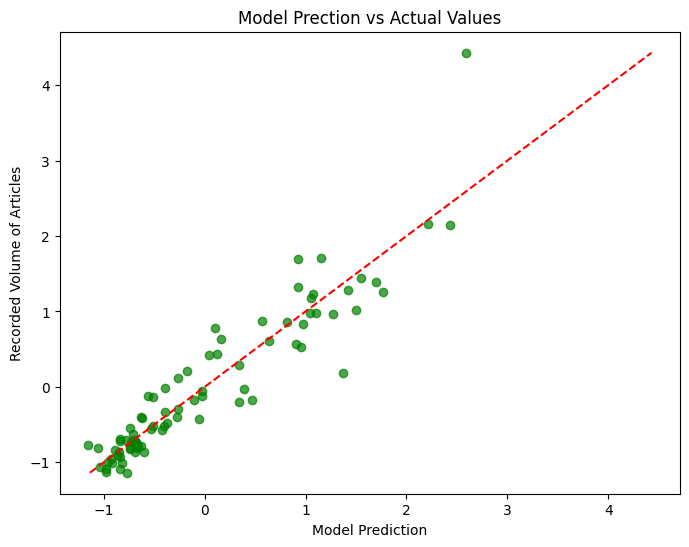

In [54]:
#graph for model prediction against actual values

fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(y_pred, zscore_df['article_vol'], alpha = 0.7, color = 'green')

#plot takes arguments in order x, y. so put the start and the end x value in first and then the start and end y value.
ax.plot([zscore_df['article_vol'].min() , zscore_df['article_vol'].max()],
        [zscore_df['article_vol'].min() , zscore_df['article_vol'].max()], color = 'red', linestyle = '--')

ax.set_title('Model Prection vs Actual Values')
ax.set_ylabel('Recorded Volume of Articles')
ax.set_xlabel('Model Prediction')

plt.show()


The graph shows that my model does not capture the extreme spikes in press coverage, which were likely caused by contextual events at the time which time constraints prevented me from investigating.

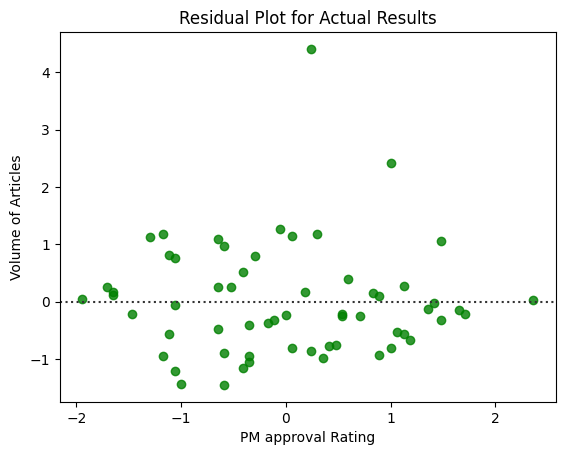

In [55]:
#residuals
import seaborn as sns
sns.residplot(zscore_df, x= 'pm_rating', y = 'article_vol', color = 'green')

plt.title('Residual Plot for Actual Results')
plt.xlabel('PM approval Rating')
plt.ylabel('Volume of Articles')

plt.show()